In [24]:
import sys
sys.path.append('../')

import warnings
warnings.filterwarnings("ignore")

from utils import *
from tqdm.auto import tqdm
import numpy as np
import pickle
import os
from model import probability_weighting

from experiment import unpack_and_dequantize

from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

In [25]:
pt_welfare = {}
for f in os.listdir("../data/gamma_alpha/pt_95/raw"):
    if ".DS_Store" in f:
        continue
    with open("../data/gamma_alpha/pt_95/raw/" + f, "rb") as file:
        data = pickle.load(file)
    alpha = data["params"]["alpha"]
    wel = sen_welfare(
        utility(
            unpack_and_dequantize(data["wealth"][:, -1], 200),
            unpack_and_dequantize(data["health"][:, -1], 200),
            alpha=alpha
        )
    )
    pt_welfare[alpha] = wel

In [27]:
alpha_vals = np.linspace(0.2, 0.8, 24)
gamma_vals = np.linspace(0.1, 0.95, 24)

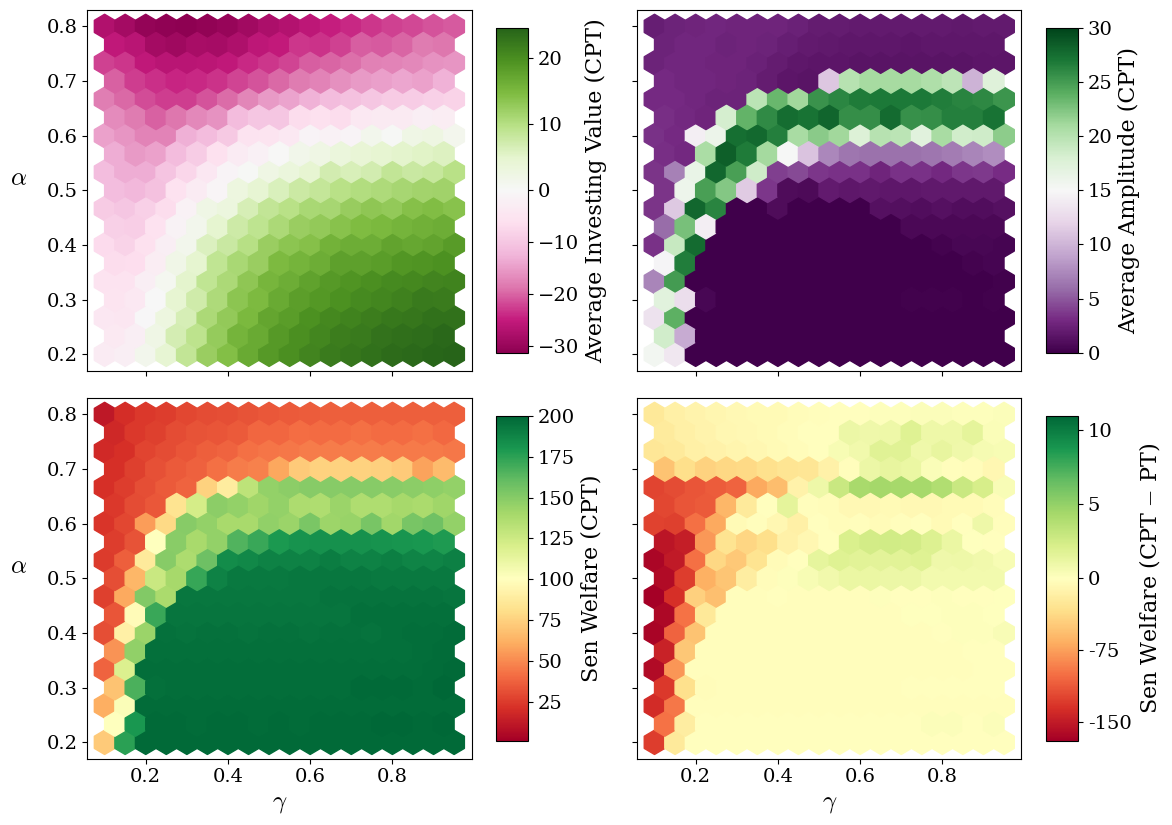

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8.5), sharey=True)

alphas = []
gammas = []
invest_values = []
welfare_values = []

for f in os.listdir("../data/gamma_alpha/cpt_95/raw"):
    try:
        parts = f.split("_")
        if len(parts) < 2: continue
        a_str, g_str = parts[0], parts[-1].replace(".pickle", "")
        a, g = float(a_str), float(g_str)

        if (np.isclose(alpha_vals, a).any() and np.isclose(gamma_vals, g).any()):

            with open("../data/gamma_alpha/cpt_95/raw/" + f, "rb") as file:
                data = pickle.load(file)

            inv = np.where(data["invest_val"] == -np.inf, -50, data["invest_val"])
            mean_inv = np.mean(inv)

            wel = sen_welfare(
                utility(
                    unpack_and_dequantize(data["wealth"][:, -1], 200),
                    unpack_and_dequantize(data["health"][:, -1], 200),
                    alpha=a
                )
            )

            alphas.append(a)
            gammas.append(g)
            invest_values.append(mean_inv)
            welfare_values.append(wel)

    except ValueError:
        continue

alphas = np.array(alphas)
gammas = np.array(gammas)
invest_values = np.array(invest_values)
welfare_values = np.array(welfare_values)

grid_size = 17

# --- PLOT (0,0): Invest Value ---
norm1 = TwoSlopeNorm(vmin=invest_values.min(), vcenter=0, vmax=invest_values.max())
hb1 = axs[0, 0].hexbin(gammas, alphas, C=invest_values,
                        gridsize=grid_size, cmap="PiYG", norm=norm1,
                        reduce_C_function=np.mean, mincnt=1)
axs[0, 0].set_ylabel(r"$\alpha$", rotation=0, labelpad=20, fontsize=18)
cbar1 = fig.colorbar(hb1, ax=axs[0, 0], shrink=0.9, aspect=10, label="Average Investing Value (CPT)")

# --- PLOT (0,1): Amplitude ---
with open("../data/gamma_alpha/cpt_95/dominant_frequencies_amplitudes.pickle", "rb") as f:
    FA = pickle.load(f)
hb2 = axs[0, 1].hexbin(gammas, alphas, C=[FA[i]["amplitudes"].mean() for i in range(len(FA))],
                        gridsize=grid_size, cmap="PRGn", vmin=0, vmax=30,
                        reduce_C_function=np.mean, mincnt=1)
cbar2 = fig.colorbar(hb2, ax=axs[0, 1], shrink=0.9, aspect=10, label="Average Amplitude (CPT)")

# --- PLOT (1,0): CPT Welfare ---
hb3 = axs[1, 0].hexbin(gammas, alphas, C=welfare_values,
                        gridsize=grid_size, cmap="RdYlGn", vmin=1, vmax=200,
                        reduce_C_function=np.mean, mincnt=1)
axs[1, 0].set_xlabel(r"$\gamma$", fontsize=18)
axs[1, 0].set_ylabel(r"$\alpha$", rotation=0, labelpad=20, fontsize=18)
cbar3 = fig.colorbar(hb3, ax=axs[1, 0], shrink=0.9, aspect=10, label="Sen Welfare (CPT)")

# --- PLOT (1,1): CPT - PT Welfare ---
pt_welfare_vals = np.array([pt_welfare[min(pt_welfare, key=lambda k: abs(k - a))] for a in alphas])
welfare_diff = welfare_values - pt_welfare_vals

diff_min = welfare_diff.min()
diff_max = welfare_diff.max()
norm4 = TwoSlopeNorm(vmin=diff_min, vcenter=0, vmax=diff_max)

hb4 = axs[1, 1].hexbin(gammas, alphas, C=welfare_diff,
                        gridsize=grid_size, cmap="RdYlGn", norm=norm4,
                        reduce_C_function=np.mean, mincnt=1)
axs[1, 1].set_xlabel(r"$\gamma$", fontsize=18)

neg_ticks = np.arange(0, diff_min - 1, -75)[::-1]
pos_ticks = np.arange(0, diff_max + 1, 5)[1:]
diff_ticks = np.concatenate([neg_ticks, pos_ticks])

cbar4 = fig.colorbar(hb4, ax=axs[1, 1], shrink=0.9, aspect=10, label=r"Sen Welfare (CPT $-$ PT)")
cbar4.set_ticks(diff_ticks)
cbar4.set_ticklabels([str(int(t)) for t in diff_ticks])

for ax in axs[0, :]:
    ax.tick_params(labelbottom=False)

fig.tight_layout()
plt.savefig("../figures/gamma_alpha.pdf", bbox_inches="tight")
plt.show()